In [24]:
import matplotlib.pyplot as plt
from matplotlib import ticker
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from drawarrow import ax_arrow
from highlight_text import fig_text
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [25]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df = (
    df.groupby("weekday", observed=False)
    .size()
    .reset_index(name="num_activities")
    .sort_values(by="weekday", ascending=True)
)

df

,weekday,num_activities
0,Monday,154
1,Tuesday,146
2,Wednesday,115
3,Thursday,154
4,Friday,91
5,Saturday,58
6,Sunday,125


# Bar Chart

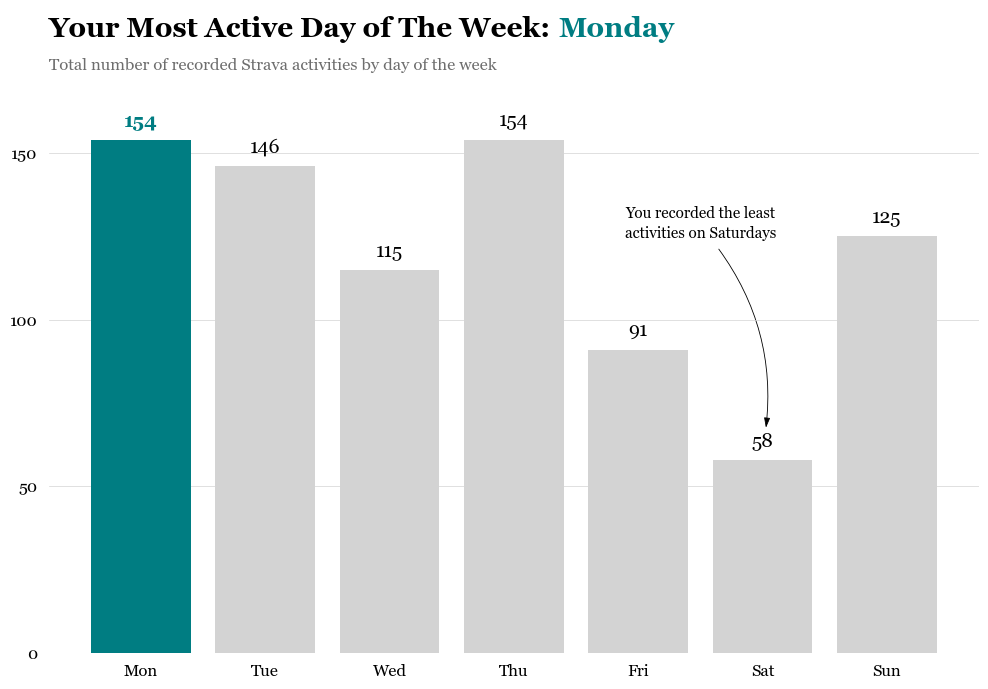

In [ ]:
# define colour palette
cmap = load_cmap("Abbott")
colours = cmap.colors

# identify weekday with the highest activity count
highlight_day = df.loc[df["num_activities"].idxmax(), "weekday"]

# map colours: highlight peak day, mute others
highlight_colour = colours[6]
colours_df = (df["weekday"] == highlight_day).map({
    True: highlight_colour,     # highlight the peak weekday
    False: "lightgrey"          # de-emphasise all other days
})

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# refine appearance of axes
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(
    axis="both",       # choose axis: "x", "y", or "both"
    length=0,          # remove x-axis and/or y-axis tick marks
    pad=8,             # increase label spacing from axis
    labelsize=12        
)

# set explicit number of x-axis & y-axis ticks to display
ax.yaxis.set_major_locator(
    ticker.MaxNLocator(nbins=4)     # use a specific Locator 
)

# refine gridlines 
ax.grid(
    axis="y",           # y-axis gridlines only 
    color="lightgrey", 
    linewidth=0.5
)

# plot bar chart
ax.bar(
    x=df["weekday"].str[:3],
    height=df["num_activities"],
    color=colours_df,
    zorder=2            # ensure bars sit above gridlines
)

# annotate bars with respective values
for i, (day, value) in enumerate(zip(df["weekday"], df["num_activities"])):
    ax.text(
        x=i,
        y=value + 3,
        s=f"{value:,}",     # value display
        va="bottom",
        ha="center",
        weight="bold" if day == highlight_day else None,
        color=highlight_colour if day == highlight_day else "black",
        fontsize=14
    )

# insight: identify lowest activity day
idx_lowest = df["num_activities"].idxmin()
lowest_day = df.loc[idx_lowest, "weekday"]
lowest_value = df["num_activities"].min()

# draw arrow pointing to the lowest bar
x_head, y_head = idx_lowest, lowest_value
x_tail, y_tail = x_head * 0.9, y_head * 2.1
ax_arrow(
    head_position=(x_head * 1.005, y_head * 1.15),
    tail_position=(x_tail * 1.03, y_tail),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=-0.2,        # curvature of line [-1, 1]
    width=0.6,          # line width
    mutation_scale=1    # scale entire arrow
)

# add explanatory annotation text
ax.text(
    x=x_tail, y=y_tail * 1.015,
    s=f"You recorded the least\nactivities on {lowest_day}s",    
    ha="center",
    va="bottom",
    fontsize=11,
    linespacing=1.45
)

# chart title
x_title, y_title = 0.125, 1.02
fig_text(
    x=x_title, y=y_title,
    s=f"Your Most Active Day of The Week: <{highlight_day}>", 
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_title, y=y_title * 0.925,
    s="Total number of recorded Strava activities by day of the week",
    size=12,
    color="#6e6e6e"
)

# save figure as an image file
plt.savefig(
    "../images/activities_by_weekday.svg",
    bbox_inches="tight"
)

plt.show()